Yuliia Chernysheva  
April 23, 2026  
CIS 2266

# **Titanic Data Analysis Project (Part2)**

This second stage of the analysis builds upon the initial Exploratory Data Analysis (EDA) of the Titanic dataset. While Part 1 focused on age-based survival and financial overview, Part 2 investigates the intersection of gender and social class to understand how these factors dictated survival outcomes.

**Research Questions**

1. **Question 1:** What is the distribution of passengers lost vs. survived by **sex**?
2. **Question 2:** What is the distribution of passengers lost vs. survived by **ticket class**?
3. **Question 3:** What is the **conditional probability** of survival given a person's sex and passenger class?

# **Data Inspection and Preparation**

## Selection and Verification of Data

To ensure the integrity of the analysis, the dataset is re-inspected. This step documents the available variables and verifies if any missing values (NaN) could affect the calculations for sex, class, or survival.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Constants for the project colors
COLOR_LOST = '#E63946'
COLOR_SURVIVED = '#0077B6'
COLOR_TEXT = '#2F2F2F'
COLOR_GRID = '#E0E0E0'

# Load Data
df = pd.read_csv('titanic.csv')

# Documenting columns and checking for missing values
print(">> Dataset Columns:")
print(df.columns.tolist())

print("\n>> Missing Values Count:")
print(df.isnull().sum())

# Data Summary
print("\n>> Data Summary:")
display(df.describe())

>> Dataset Columns:
['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'Siblings/Spouses Aboard', 'Parents/Children Aboard', 'Fare']

>> Missing Values Count:
Survived                   0
Pclass                     0
Name                       0
Sex                        0
Age                        0
Siblings/Spouses Aboard    0
Parents/Children Aboard    0
Fare                       0
dtype: int64

>> Data Summary:


,Survived,Pclass,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
count,887.000000,887.000000,887.000000,887.000000,887.000000,887.00000
mean,0.385569,2.305524,29.471443,0.525366,0.383315,32.30542
std,0.487004,0.836662,14.121908,1.104669,0.807466,49.78204
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.00000
25%,0.000000,2.000000,20.250000,0.000000,0.000000,7.92500
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.45420
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.13750
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.32920


## *Technical Summary*

* **Data Integrity:** The dataset is complete, with no missing values in the **Sex**, **Pclass**, or **Survived** columns. This allows for a precise calculation of survival probabilities without data cleaning.
* **Variable Types:** The analysis will utilize categorical data (**Sex** and **Class**) to group passengers and numerical data (**Survived**) to measure outcomes.
* **Ready for Analysis:** With the data structure verified, the investigation can now proceed to analyze how gender and social standing directly influenced survival rates.

# **Research Question 1: Survival by Sex**

**Question:** What is the distribution of passengers lost vs. survived based on their gender?

To answer this, the data is grouped by the *Sex* and *Survived* columns. This transformation allows us to see the exact count of outcomes for both men and women.

>> Survival Count by Sex:


,Lost,Survived
Sex,,
female,81,233
male,464,109


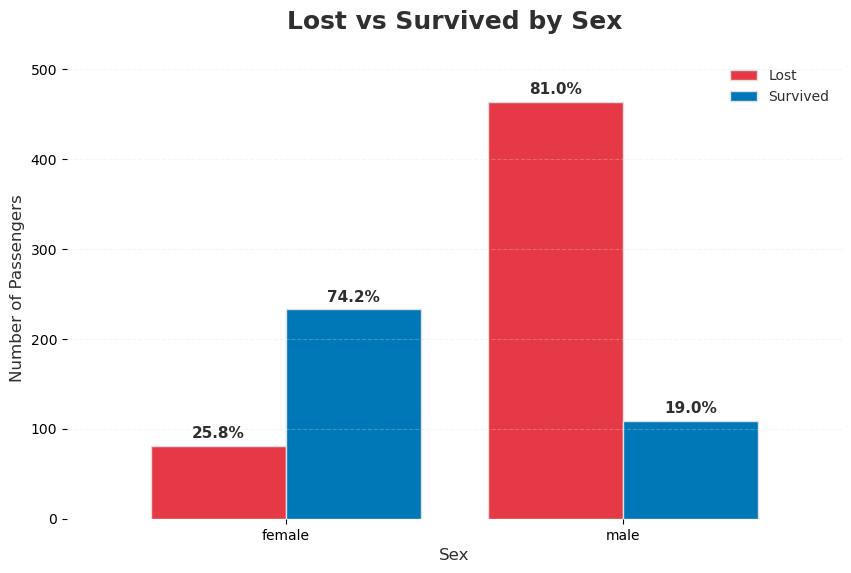

In [2]:
# Grouping by Sex and Survival
sex_survival = df.groupby(['Sex', 'Survived']).size().unstack()
sex_survival.columns = ['Lost', 'Survived']

print(">> Survival Count by Sex:")
display(sex_survival)

# Visualization: Bar Chart
chart_colors = [COLOR_LOST, COLOR_SURVIVED]

ax = sex_survival.plot(kind='bar', figsize=(10,6), color=chart_colors, 
                         width=0.8, edgecolor=COLOR_GRID)

# Add Percentage 
for i, gender in enumerate(sex_survival.index):
    # two columns for each sex: Died (0) and Survived (1)
    for j, survived_status in enumerate([0, 1]):
        # Locate the specific patch(bar)
        # Indexing in patches works as follows
        p = ax.patches[j * len(sex_survival) + i]
        height = p.get_height()
        total_in_class = sex_survival.loc[gender].sum()
        percentage = f'{(height/total_in_class):.1%}'
        
        ax.annotate(percentage, (p.get_x() + p.get_width()/2, height + 5),
                ha='center', va='bottom', fontsize=11,
                fontweight='bold', color=COLOR_TEXT)

# Settings
plt.title('Lost vs Survived by Sex', color=COLOR_TEXT, fontweight='bold', 
          fontsize=18, pad=20)
plt.xlabel('Sex', color=COLOR_TEXT, fontsize=12)
plt.ylabel('Number of Passengers', color=COLOR_TEXT, fontsize=12)
plt.legend(labelcolor=COLOR_TEXT, frameon=False)
plt.xticks(rotation=0)
plt.grid(axis='y', color=COLOR_GRID, linestyle='--', alpha=0.3)
plt.box(False)

# Increase the limit on Y
plt.ylim(0, sex_survival.values.max() + 50)

plt.show()

**Analysis of Question 1:**

**Stark Contrast:** The data reveals a massive survival gap between genders. Female passengers had a survival rate of over 70%, while the majority of males were lost.

**Conclusion:** This statistically supports the historical "women and children first" policy, making Sex one of the strongest predictors of survival in the Titanic disaster.

# **Research Question 2: Survival by Class**

**Question:** How did the passenger class affect the number of people who were lost or survived? 

To analyze the impact of socio-economic status, the dataset is grouped by *Pclass* and *Survived*. This transformation aggregates individual records into a summary of outcomes for each of the three ticket classes.

>> Survival Count by Ticket Class:


,Lost,Survived
Pclass,,
1,80,136
2,97,87
3,368,119


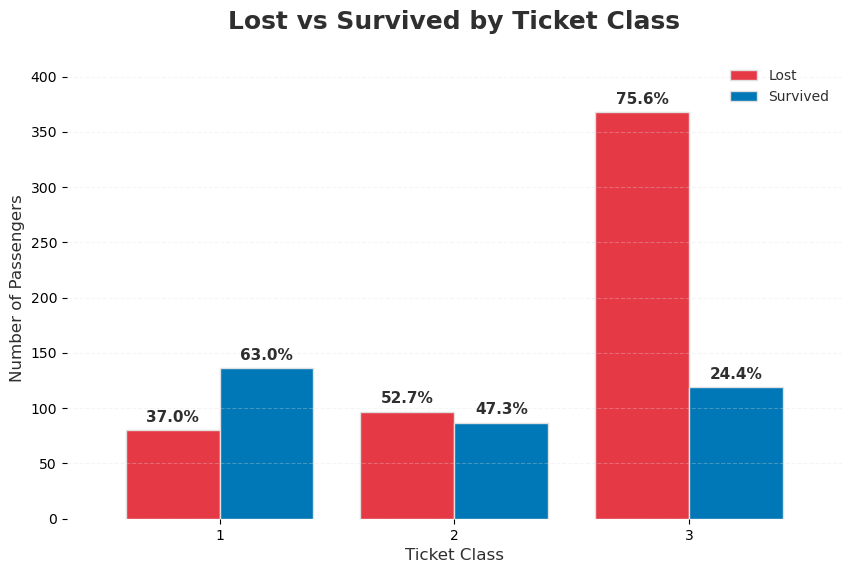

In [3]:
# Group by Pclass and Survival
class_survival = df.groupby(['Pclass', 'Survived']).size().unstack()
class_survival.columns = ['Lost', 'Survived']

print(">> Survival Count by Ticket Class:")
display(class_survival)

ax = class_survival.plot(kind='bar', figsize=(10,6), color=chart_colors, 
                         width=0.8, edgecolor=COLOR_GRID)

# Add Percentage 
for i, pclass in enumerate(class_survival.index):
    # two columns for each class: Died (0) and Survived (1)
    for j, survived_status in enumerate([0, 1]):
        # Locate the specific patch(bar)
        # Indexing in patches works as follows
        p = ax.patches[j * len(class_survival) + i]
        height = p.get_height()
        total_in_class = class_survival.loc[pclass].sum()
        percentage = f'{(height/total_in_class):.1%}'
        
        ax.annotate(percentage, (p.get_x() + p.get_width()/2, height + 5),
                ha='center', va='bottom', fontsize=11,
                fontweight='bold', color=COLOR_TEXT)

# Settings
plt.title('Lost vs Survived by Ticket Class', color=COLOR_TEXT, 
          fontweight='bold', fontsize=18, pad=20)
plt.xlabel('Ticket Class', color=COLOR_TEXT, fontsize=12)
plt.ylabel('Number of Passengers', color=COLOR_TEXT, fontsize=12)
plt.legend(labelcolor=COLOR_TEXT, frameon=False)
plt.xticks(rotation=0)
plt.grid(axis='y', color=COLOR_GRID, linestyle='--', alpha=0.3)
plt.box(False)

# Increase the limit on Y
plt.ylim(0, class_survival.values.max() + 50)

plt.show()

**Analysis Summary:**

* **First Class Advantage:** Passengers in 1st class had the highest survival rate (**63.0%**), representing the only group where survivors outnumbered casualties.
* **The Struggle of the 3rd Class:** In contrast, 3rd class passengers faced a tragic mortality rate, with only **24.4%** survival and over 350 lives lost.
* **The Middle Ground:** 2nd class survival was nearly a 50/50 split, at **47.3%**.

**Conclusion:** Social standing (Pclass) was a critical determinant of survival, often overriding other demographic factors during the disaster.

# **Research Question 3: Conditional Probability of Survival**

**Question:** What is the conditional probability that a person survives given their sex and passenger-class?

To find the probability for each specific group (e.g., a female in 1st class), we calculate the **mean** of the Survived column after grouping by both Sex and Pclass. Since Survived is coded as 0 and 1, the average value directly represents the probability of survival.

>> Conditional Survival Analysis (Summary Table):


,Sex,Ticket Class,Total Passengers,Survivors,Survival Rate (%)
0,female,1,94,91,96.8%
1,female,2,76,70,92.1%
2,female,3,144,72,50.0%
3,male,1,122,45,36.9%
4,male,2,108,17,15.7%
5,male,3,343,47,13.7%


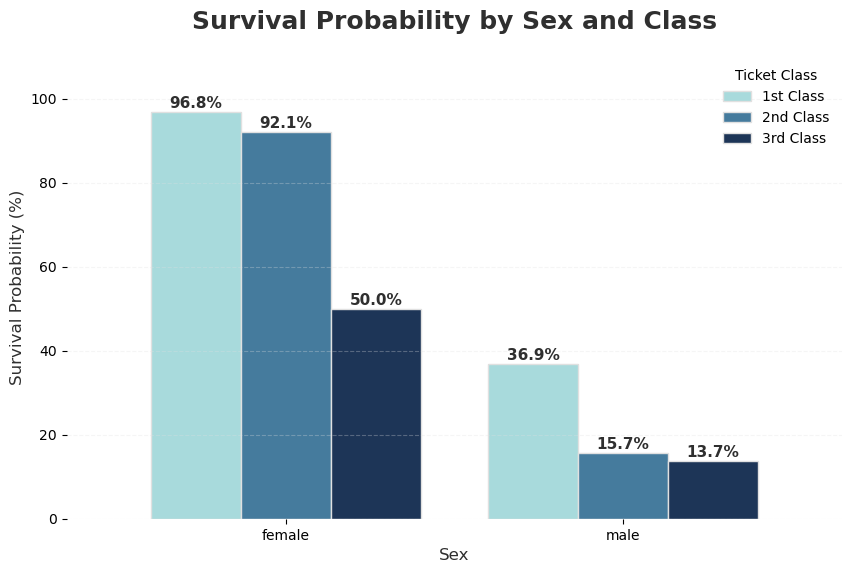

In [4]:
# Conditional probability: P(Survival | Sex, Class)
# Group by Sex and Pclass
# Calculate sum (survivors), count (total), and mean (probability)
stats = df.groupby(['Sex','Pclass'])['Survived'].agg(
    survived_count='sum',
    passengers='count',
    survival_prob='mean'
).reset_index()

# Create a text percentage for display
stats['survival_prob_pct'] = (stats['survival_prob'] * 100).round(1).astype(str) + '%'

# Rename columns before outputting
final_table = stats.rename(columns={
    'Sex': 'Sex',
    'Pclass': 'Ticket Class',
    'passengers': 'Total Passengers',
    'survived_count': 'Survivors',
    'survival_prob_pct': 'Survival Rate (%)' 
})[['Sex', 'Ticket Class', 'Total Passengers', 'Survivors', 'Survival Rate (%)']]

print(">> Conditional Survival Analysis (Summary Table):")
display(final_table)

# Visualization: Grouped Bar Chart for Probabilities
chart_data = stats.pivot(index='Sex', columns='Pclass', 
                        values='survival_prob') * 100
ax = chart_data.plot(kind='bar', figsize=(10, 6),
                     color=['#A8DADC', '#457B9D', '#1D3557'],
                     edgecolor=COLOR_GRID, width=0.8)

# Adding labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
               (p.get_x() + p.get_width() / 2, p.get_height() + 2),
               ha='center', va='center', fontsize=11,
               fontweight='bold', color=COLOR_TEXT)
    
plt.title('Survival Probability by Sex and Class', color=COLOR_TEXT, 
          fontweight='bold', fontsize=18, pad=20)
plt.xlabel('Sex', color=COLOR_TEXT, fontsize=12)
plt.ylabel('Survival Probability (%)', color=COLOR_TEXT, fontsize=12)
plt.legend(['1st Class', '2nd Class', '3rd Class'], title='Ticket Class', 
           frameon=False)

plt.xticks(rotation=0)
plt.grid(axis='y', color=COLOR_GRID, linestyle='--', alpha=0.3)
plt.box(False)
plt.ylim(0,110) # Probability doesn't exceed 100%
plt.show()

**Analysis of Results**

* **The "Women and Children First" Reality:** The probability for females in 1st Class was the highest at 96.8%, and 92.1% for 2nd Class. This shows that being female in a higher class almost guaranteed survival.
* **The 3rd Class Divide:** Even for women, being in 3rd Class dropped the survival probability significantly to 50.0%.
* **Male Mortality:** Men in all classes faced low probabilities, but the drop-off is extreme: while 36.9% of 1st-class men survived, only 13.7% of 3rd-class men did.

**Conclusion:** The conditional probability proves that while gender was the primary factor, the passenger class acted as a secondary filter that drastically altered one's chances of survival.

# **Final Conclusion**

The final analysis of the Titanic dataset demonstrates that passenger survival was largely dictated by social status and gender, reflecting the rigid maritime traditions and class hierarchies of the era.

**Key Findings:**

* **The Gender Factor:** Biological sex was the primary determinant of survival. Due to the "women and children first" protocol, the survival rate for females exceeded **70%**, while the vast majority of male passengers were lost.
* **Class Inequality:** Passenger class acted as a critical secondary filter. Those with higher-class tickets had better access to the boat deck, resulting in a **63.0%** survival rate in 1st Class compared to only **24.4%** in 3rd Class.
* **The Combined Effect:** The conditional probability analysis highlights how class influenced chances even within the same gender. For instance, women in 3rd Class had a **50.0%** survival rate, significantly lower than their counterparts in 1st and 2nd Class.
* **Male Survival Trends:** Even 1st Class status did not guarantee safety for men; their survival probability was **36.9%**, though this was still nearly three times higher than that of men in 3rd Class (**13.7%**).

**Summary:**

The data confirms that an individual's life expectancy on the night of the disaster was not a matter of luck. The combination of gender and ticket price effectively predetermined the fate of most passengers, making the Titanic disaster a clear historical example of socio-economic inequality.